In [9]:
import sys
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import pickle


In [4]:
# Read in data from all three tree building methods
main_dir = "/grid/siepel/home/staklins/projects/crispr_barcode/results/beam/latest_results/uniform_50cells_50sites_0.0025mut_10-6mig_data_8_24_24"
laml_pr_file = f"{main_dir}/precision_recall_curve/precision_recall_vars.pkl"
laml_f1_file = f"{main_dir}/precision_recall_curve/metrics.csv"
cass_pr_file = f"{main_dir}/cas_greedy_tree_runs_11_10_25/precision_recall_curve/precision_recall_vars.pkl"
cass_f1_file = f"{main_dir}/cas_greedy_tree_runs_11_10_25/precision_recall_curve/metrics.csv"
true_pr_file = f"{main_dir}/ground_truth_tree_runs_11_10_25/precision_recall_curve/precision_recall_vars.pkl"
true_f1_file = f"{main_dir}/ground_truth_tree_runs_11_10_25/precision_recall_curve/metrics.csv"

In [16]:
all_pr_files = [cass_pr_file, laml_pr_file, true_pr_file]
titles = ["Cassiopeia-greedy tree", "LAML tree", "True tree"]

all_pr_data = {}  # store title : nested dict

for i, (file, title) in enumerate(zip(all_pr_files, titles)):
    with open(file, "rb") as f:
        (
            pathfinder_precisions,
            pathfinder_recalls,
            machina_precisions,
            machina_recalls,
            random_precisions,
            random_recalls,
            consensus_precisions,
            consensus_recalls,
            parsimony_precisions,
            parsimony_recalls,
            metient_df,
            mach2_df,
            beam_df,
        ) = pickle.load(f)

    # Compute averages
    if i == 1:  # only for the LAML tree case
        avg_pathfinder_precision = np.nanmean(pathfinder_precisions)
        avg_pathfinder_recall = np.nanmean(pathfinder_recalls)
    else:
        avg_pathfinder_precision = None
        avg_pathfinder_recall = None

    avg_machina_precision = np.nanmean(machina_precisions)
    avg_machina_recall = np.nanmean(machina_recalls)
    avg_random_precision = np.nanmean(random_precisions)
    avg_random_recall = np.nanmean(random_recalls)
    avg_consensus_precision = np.nanmean(consensus_precisions)
    avg_consensus_recall = np.nanmean(consensus_recalls)
    avg_parsimony_precision = np.nanmean(parsimony_precisions)
    avg_parsimony_recall = np.nanmean(parsimony_recalls)

    # Process PR curves
    if i == 1:  # only for the LAML tree case
        avg_beam_df = beam_df.groupby("Threshold")[["precision", "recall"]].mean().reset_index()
    else:
        avg_beam_df = None

    avg_metient_df = metient_df.groupby("Threshold")[["precision", "recall"]].mean().reset_index()
    mach2_df = mach2_df.groupby("Threshold")[["precision", "recall"]].mean().reset_index()

    # Store as nested dictionary
    all_pr_data[title] = {
        "pathfinder": {
            "precision": avg_pathfinder_precision,
            "recall": avg_pathfinder_recall,
        },
        "machina": {
            "precision": avg_machina_precision,
            "recall": avg_machina_recall,
        },
        "random": {
            "precision": avg_random_precision,
            "recall": avg_random_recall,
        },
        "consensus": {
            "precision": avg_consensus_precision,
            "recall": avg_consensus_recall,
        },
        "parsimony": {
            "precision": avg_parsimony_precision,
            "recall": avg_parsimony_recall,
        },
        "beam_df": avg_beam_df,
        "metient_df": avg_metient_df,
        "mach2_df": mach2_df,
    }

In [17]:
# Copy BEAM and Pathfinder data from LAML to other tree data
laml_data = all_pr_data["LAML tree"]

for title in ["Cassiopeia-greedy tree", "True tree"]:
    # Copy Pathfinder precision/recall
    all_pr_data[title]["pathfinder"]["precision"] = laml_data["pathfinder"]["precision"]
    all_pr_data[title]["pathfinder"]["recall"] = laml_data["pathfinder"]["recall"]

    # Copy BEAM averaged precision–recall dataframe
    all_pr_data[title]["beam_df"] = laml_data["beam_df"]

In [ ]:
# Create figure and axes
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
fs = 24
size = 500
textsize = 18


# Define color palette for main comparison plot
method_colors = {
    "BEAM": "red",
    "Random": "black",
    "Fitch-Hartigan": "purple",
    "PathFinder": "orange",
    "MACHINA": "gold",
    "Metient": "green",
    "Consensus": "blue",
    "MACH2": "navy",
}

for i, (ax, title) in enumerate(zip(axes, titles)):
    data = all_pr_data[title]  # Get nested dict for this dataset

    # === BEAM curve + markers ===
    beam_df = data["beam_df"]
    if beam_df is not None and not beam_df.empty:
        ax.plot(
            beam_df["recall"],
            beam_df["precision"],
            color=method_colors["BEAM"],
            label="BEAM",
            lw=2.5,
        )
        for thresh, marker in zip([0.50, 0.90], ["o", "s"]):
            df_thresh = beam_df[beam_df["Threshold"] == thresh]
            if not df_thresh.empty:
                ax.scatter(
                    df_thresh["recall"],
                    df_thresh["precision"],
                    facecolors=method_colors["BEAM"],
                    edgecolors=method_colors["BEAM"],
                    s=size / 3,
                    marker=marker,
                    label=f"BEAM {thresh:.2f}",
                )
                
    # === MACH2 ===
    mach2_df = data["mach2_df"]
    if mach2_df is not None and not mach2_df.empty:
        ax.plot(
            mach2_df["recall"],
            mach2_df["precision"],
            color=method_colors["MACH2"],
            label="MACH2",
            lw=2.5,
        )

    # === Metient ===
    metient_df = data["metient_df"]
    if metient_df is not None and not metient_df.empty:
        ax.plot(
            metient_df["recall"],
            metient_df["precision"],
            color=method_colors["Metient"],
            label="Metient",
            lw=2.5,
        )

    # === Single-point methods ===
    single_point_methods = [
        ("PathFinder", data["pathfinder"]["recall"], data["pathfinder"]["precision"]),
        ("MACHINA", data["machina"]["recall"], data["machina"]["precision"]),
        ("Fitch-Hartigan", data["parsimony"]["recall"], data["parsimony"]["precision"]),
        ("Consensus", data["consensus"]["recall"], data["consensus"]["precision"]),
        ("Random", data["random"]["recall"], data["random"]["precision"]),
    ]

    for name, recall, precision in single_point_methods:
        if recall is not None and precision is not None:
            if not (np.isnan(recall) or np.isnan(precision)):
                ax.scatter(
                    recall,
                    precision,
                    color=method_colors.get(name, "grey"),
                    s=size,
                    marker="x",
                    label=name,
                )

    # === Axis formatting ===
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Recall", fontsize=textsize)
    if i == 0:
        ax.set_ylabel("Precision", fontsize=textsize)
    ax.set_title(title, fontsize=textsize)
    ax.tick_params(axis="both", which="major", labelsize=textsize)
    
    ax.xaxis.set_major_locator(MultipleLocator(0.25))
    ax.yaxis.set_major_locator(MultipleLocator(0.25))

    # === Legend on the rightmost panel only ===
    if i == len(titles) - 1:
        ax.legend(
            bbox_to_anchor=(1.05, 0.5),
            loc="center left",
            fontsize=14,
            edgecolor="none",
        )

plt.tight_layout()
plt.savefig(f"{main_dir}/precision_recall_all_tree_methods.pdf")
# plt.show()
plt.close()


In [11]:
def preprocess_f1_data(f1_file):
    f1_df = pd.read_csv(f1_file)
    f1_columns = [col for col in f1_df.columns if "f1" in col and not col.startswith("Metient_bestSol")]
    f1_df = f1_df[f1_columns]
    f1_df.columns = [col.replace("_f1", "") for col in f1_df.columns]
    desired_order = ["Random", "Consensus", "Fitch-Hartigan", "MACHINA", "PathFinder", "Metient", "MACH2", "BEAM"]
    f1_df = f1_df[desired_order]
    return f1_df
    

In [12]:
f1_laml = preprocess_f1_data(laml_f1_file)
f1_cass = preprocess_f1_data(cass_f1_file)
f1_true = preprocess_f1_data(true_f1_file)

In [20]:
# Copy over f1_laml data to others for beam and pathfinder since those methods do not depend on an input tree
f1_cass["BEAM"] = f1_laml["BEAM"]
f1_true["BEAM"] = f1_laml["BEAM"]
f1_cass["PathFinder"] = f1_laml["PathFinder"]
f1_true["PathFinder"] = f1_laml["PathFinder"]

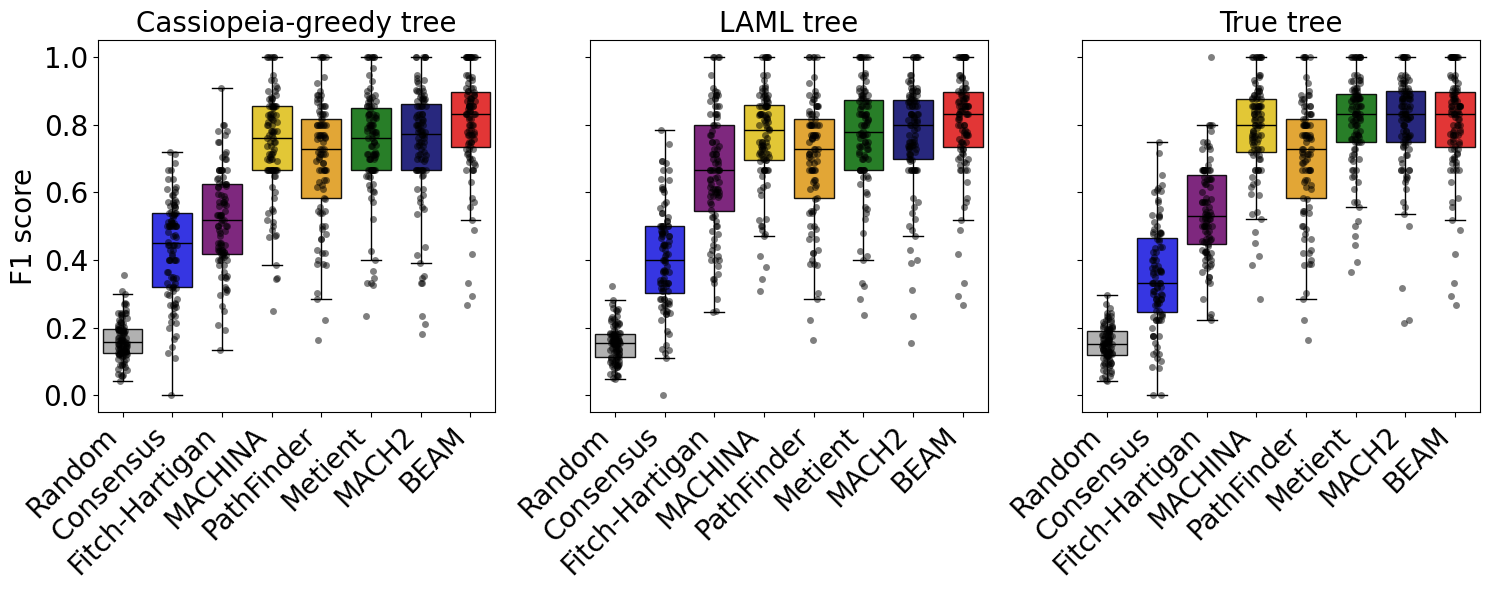

In [24]:
# Create figure and axes
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
fs = 20

# List of datasets and titles
datasets = [
    ("Cassiopeia-greedy tree", f1_cass),
    ("LAML tree", f1_laml),
    ("True tree", f1_true),
]

# Methods to apply hatching for
hatched_methods = ["BEAM", "PathFinder"]

# Plot each dataset
for ax_idx, (ax, (title, df)) in enumerate(zip(axes, datasets)):
    # Get ordered colors for columns in this dataset
    colors = [method_colors[col] for col in df.columns]

    sns.boxplot(
        data=df,
        orient="v",
        showfliers=False,
        palette=colors,
        boxprops=dict(edgecolor="black", alpha=0.9),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
        ax=ax
    )

    sns.stripplot(
        data=df,
        orient="v",
        color="black",
        alpha=0.5,
        ax=ax,
    )
    
    # # Apply hatch pattern to BEAM and PathFinder for first and last plots
    # if ax_idx in [0, 2]:
    #     for patch, method in zip(ax.patches, df.columns):
    #         if method in hatched_methods:
    #             patch.set_hatch("//")
    #             patch.set_edgecolor("black")

    ax.set_title(title, fontsize=fs)
    ax.set_ylabel("F1 score" if ax == axes[0] else "", fontsize=fs)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis='x', rotation=45, labelsize=fs)
    ax.tick_params(axis='y', labelsize=fs)

    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()
# plt.savefig(f"{main_dir}/f1_score_all_tree_methods.pdf")
plt.show()
plt.close()
